---

# ⚖️ **Weight Initialization Techniques in Deep Learning**  
> *Set the stage right before training even begins!* 🎬

---

## ✅ **What is Weight Initialization?**

📌 **Weight Initialization** is the process of assigning **initial values** to the weights of a neural network **before training** begins.

> Why does it matter?  
> Because **bad initialization** can lead to:
- ❌ Slow convergence  
- ❌ Vanishing/exploding gradients  
- ❌ Getting stuck in poor local minima  
- ❌ Symmetry problem (where all neurons learn the same thing)

---

## 🧠 **Goals of Good Initialization**

1. Maintain **signal variance** through layers  
2. Prevent **vanishing or exploding** gradients  
3. Break **symmetry** between neurons  
4. Enable **faster and stable convergence**

---

## 🔢 **Types of Weight Initialization Techniques**

---

### 🔹 **1. Zero Initialization** ❌
```python
w = 0
```
🚫 **Do NOT do this!**  
All neurons will learn the same thing → no symmetry breaking.  
Gradients will be identical → useless.

---

### 🔹 **2. Random Initialization**
```python
w = np.random.randn() * 0.01
```
✅ Breaks symmetry  
❌ Might cause vanishing gradients in deep networks  
(too small weights shrink activations and gradients)

---

### 🔹 **3. Xavier Initialization (a.k.a. Glorot Initialization)**  
> Proposed by **Xavier Glorot** (2010)

$
W \sim \mathcal{N}(0, \frac{1}{n_{\text{in}}}) \quad \text{(normal)} \\
W \sim U\left(-\frac{\sqrt{6}}{\sqrt{n_{\text{in}} + n_{\text{out}}}}, \frac{\sqrt{6}}{\sqrt{n_{\text{in}} + n_{\text{out}}}} \right) \quad \text{(uniform)}
$

- Good for **sigmoid** or **tanh** activations  
- Balances variance of weights forward and backward  

✅ Prevents exploding/vanishing gradients in shallow nets  
❌ Not ideal for **ReLU** activations

---

### 🔹 **4. He Initialization (a.k.a. Kaiming Initialization)**  
> Designed for **ReLU**-based networks

$
W \sim \mathcal{N}(0, \frac{2}{n_{\text{in}}}) \\
W \sim U\left(-\sqrt{\frac{6}{n_{\text{in}}}}, \sqrt{\frac{6}{n_{\text{in}}}} \right)
$

- Assumes ReLU kills half the activations  
- Used in **ResNets**, **CNNs**, and **MLPs with ReLU**

✅ Ideal for deep ReLU networks  
🚀 Fast convergence and stable gradients

---

### 🔹 **5. LeCun Initialization**
> Suitable for **Leaky ReLU** or **SELU**

$
W \sim \mathcal{N}(0, \frac{1}{n_{\text{in}}})
$

✅ Used with **SELU** activation (self-normalizing networks)

---

### 🔹 **6. Orthogonal Initialization**
> Ensures initial weight matrix is **orthogonal**

✅ Preserves norms  
✅ Works well for **RNNs** and **deep feedforward nets**

---

### 🔹 **7. Constant / Custom Initialization**
Use fixed or handcrafted values when you have **prior knowledge**.

---

## 💻 **How to Use in Code (Keras & PyTorch)**

### ✅ Keras
```python
from tensorflow.keras.initializers import HeNormal, GlorotUniform

model.add(Dense(128, activation='relu', kernel_initializer=HeNormal()))
```

### ✅ PyTorch
```python
import torch.nn as nn
nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
nn.init.xavier_uniform_(layer.weight)
```

---

## 📊 **Comparison Table**

| Initialization     | Best For        | Formula (Variance)            | Activation Type      |
|--------------------|------------------|-------------------------------|----------------------|
| **Zero**           | ❌ Never use      | 0                             | —                    |
| **Random (small)** | Small nets only  | ~0.01                         | Any                  |
| **Xavier / Glorot**| Sigmoid / Tanh   | 1 / (n_in + n_out)            | Sigmoid / Tanh       |
| **He (Kaiming)**   | ReLU / Leaky ReLU| 2 / n_in                      | ReLU, Leaky ReLU     |
| **LeCun**          | SELU             | 1 / n_in                      | SELU                 |
| **Orthogonal**     | RNNs, deep nets  | Orthogonal matrix             | Any                  |

---

## 🧠 **Best Practices**

✅ Use **He Initialization** for **ReLU-based** networks  
✅ Use **Xavier Initialization** for **Tanh/Sigmoid**  
✅ Always **scale** your inputs (feature scaling!)  
✅ Combine with **BatchNorm** if training is unstable  
✅ Monitor gradients → use proper init to prevent vanishing/exploding

---

## 🎯 Summary

- Initialization **matters more** in deep nets  
- Poor init = poor training dynamics  
- Choose based on **activation function**  
- Helps with **faster convergence** and **model stability**

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Adityarajora/Complete-KNN-visualization/refs/heads/master/1.ushape.csv')

In [3]:
df.columns = ['X', 'Y', 'class']

In [4]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


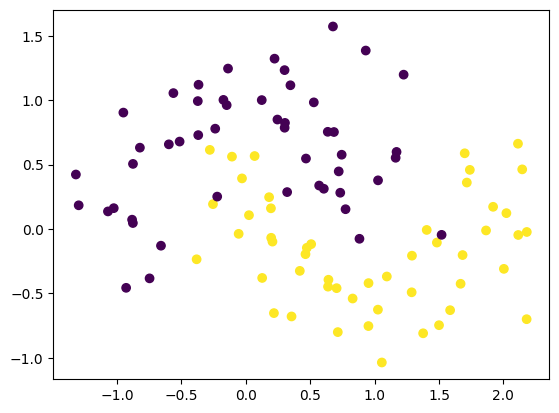

In [6]:
plt.scatter(df['X'],df['Y'],c=df['class'])
plt.show()

In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
import warnings
warnings.filterwarnings('ignore')

### **He Initialization (a.k.a. Kaiming Initialization)**

In [10]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.get_weights()

[array([[-1.4409677 ,  0.7077047 ,  0.07752428,  0.56682885, -1.2958345 ,
         -0.93637115, -1.0483445 , -0.2712195 ,  0.33839354,  1.3903642 ],
        [ 2.016861  , -1.6751493 ,  0.6096572 , -1.409786  ,  0.38059065,
         -2.0867424 , -0.5954034 , -1.6616508 ,  1.2365994 ,  1.6813701 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.82543933,  0.56618357, -0.77196527, -0.2966923 ,  0.15885025,
         -0.35622433, -0.58409077, -0.4429878 , -0.08352566,  0.59037113],
        [ 0.15296412, -0.54536676,  0.00782607, -0.1515941 ,  0.7917201 ,
         -0.13401596,  0.7558261 , -0.5079061 , -0.73855555, -0.0191585 ],
        [ 0.13730066,  0.145612  , -0.08809966,  0.7942912 , -0.19253118,
         -0.22751547,  0.18726371,  0.9139617 , -0.06393696,  0.01704996],
        [-0.42027023,  0.0579637 , -0.71270657, -0.40061983, -0.3432951 ,
          0.03601123,  0.48539165,  0.01075822, -0.9566626 ,  0.1434225 ],
        [-0.09905

In [12]:
initial_weights = model.get_weights()

In [13]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [14]:
model.set_weights(initial_weights)

In [15]:
model.get_weights()

[array([[-0.00444914, -0.6016587 ,  1.2992437 , -0.0660526 , -0.01764781,
          0.30919605, -0.8688544 ,  0.5230973 ,  1.896034  ,  0.22255498],
        [-0.4077499 , -0.7809016 ,  0.8615925 , -0.31706265,  1.236751  ,
         -0.14513858,  0.1822548 ,  0.7618831 , -0.23072977, -1.3986224 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.33598912, -0.38608453,  0.00455977,  0.5926358 ,  0.4155546 ,
          0.08593499,  0.09508777,  0.31823948,  0.49463552, -0.20404777],
        [ 0.11268389, -0.1548045 ,  0.6812015 ,  0.32493916,  0.09920581,
          0.3790475 ,  0.18719654, -0.07449763, -0.3380141 , -0.42626366],
        [-0.17024483, -0.0731334 , -0.34585428, -0.07092905, -0.00473879,
         -0.21560062, -0.278866  , -0.20675254, -0.17742196,  0.19137098],
        [ 0.0476962 ,  0.05071231, -0.09322107, -0.04133634, -0.1975559 ,
         -0.10155263, -0.10716711, -0.19955821,  0.19487816, -0.12675849],
        [-0.09166

In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.6139 - loss: 0.6920 - val_accuracy: 0.7500 - val_loss: 0.6864
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5811 - loss: 0.6909 - val_accuracy: 0.7500 - val_loss: 0.6844
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5890 - loss: 0.6897 - val_accuracy: 0.8000 - val_loss: 0.6826
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6392 - loss: 0.6887 - val_accuracy: 0.7500 - val_loss: 0.6808
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6407 - loss: 0.6872 - val_accuracy: 0.8000 - val_loss: 0.6787
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6329 - loss: 0.6863 - val_accuracy: 0.8000 - val_loss: 0.6765
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6109 - loss: 0.6856 - val_accuracy: 0.8000 - val_loss: 0.6739
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6124 - loss: 0.6830 - val_accuracy: 0.8000 - val_loss

In [18]:
model.get_weights()

[array([[ 0.09297083, -0.8108414 ,  1.2990291 ,  0.12373934, -0.0895597 ,
          0.3977585 , -1.0841095 ,  0.6978631 ,  2.0077562 ,  0.4973869 ],
        [-0.6893672 , -0.8495472 ,  0.71058327, -0.45765308,  1.4613407 ,
         -0.40044168,  0.23897856,  0.8867432 , -0.12890168, -1.5426323 ]],
       dtype=float32),
 array([ 0.11225796,  0.11050683, -0.05757446,  0.14137122,  0.11852109,
         0.02562536, -0.07669256,  0.13895987, -0.06274158,  0.23384447],
       dtype=float32),
 array([[ 0.34190705, -0.37530386,  0.15555362,  0.8729051 ,  0.4350943 ,
          0.38556284, -0.01365098,  0.31823948,  0.5080316 ,  0.07661863],
        [ 0.2662741 , -0.05195411,  0.9066432 ,  0.2381921 ,  0.21833408,
          0.42988488,  0.3414902 , -0.07449763, -0.17198785, -0.34118518],
        [-0.11722355, -0.09079377, -0.3645329 ,  0.03616903,  0.06113597,
         -0.05070675, -0.17668022, -0.20675254, -0.05452946,  0.26867166],
        [ 0.02364403,  0.06001811,  0.02195491,  0.213126  , 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


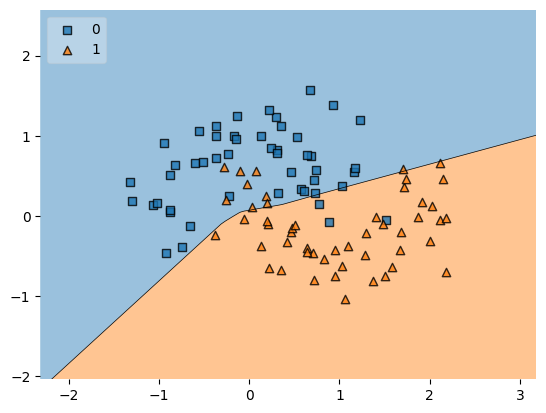

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)
plt.show()

In [20]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.023242732374742482)

In [21]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.022277319017230984)

---